In [1]:
from torch.utils.data import Dataset, DataLoader, random_split
import torch
import torch.nn as nn
import torch.nn.functional as F
from math import pi
import torch.nn as nn
from kornia.losses import total_variation
from monai.losses import DiceLoss, DiceCELoss, SoftclDiceLoss, DiceFocalLoss, NACLLoss
from tqdm import tqdm, tqdm_notebook
from sklearn.metrics import mean_squared_error
from monai.losses.dice import *  # NOQA
from IPython.display import clear_output
from monai import metrics
import monai
from matplotlib import pyplot as plt
import tempfile, os
import copy
import warnings
warnings.filterwarnings("ignore")
from tqdm import tqdm, tqdm_notebook
import wandb
import random
import torchio as tio
from torchio.data import UniformSampler, Queue


from Models.models import Siren, Finer
from Utils.utils import get_full_img, norm, get_device, dice_stack_helper, get_model, ClearCache
from Data.load_data_3d import load_data, get_gt_seg
from Utils.defaults import default_config
from Utils.plotting_utils2 import plot_seg_results_paper, plot_final_results_paper, plot_hf_results_paper
from Utils.plotting_utils import loss_plot, plot_image_metrics, plot_4_images
from LFSynth.ContrastModulation import ContrastModulation
from test3D import visualize_volume_slices

In [2]:
config = copy.deepcopy(default_config)
config["in_features"] = 3
hf_ground_truth, lf_gt, prior_seg_dice, lf_gt_seg_dice, M = load_data(1, config) #uncomment

Device =  mps
torch.Size([87, 96, 192])
BG Noise in different regions : 4.7445857300717 4.415978248235479 4.956849146645869 4.8247938816077935
known_m =  [0.75 0.9  0.9 ]
[[ 28.84998854   0.          -7.89492106]
 [ 28.84998854 -22.35619149   0.        ]
 [  0.          22.35619149  -7.89492106]] [14.53206245  1.51691906 13.01514339]
             m_init  epsilon  \
0   [0.1, 0.1, 0.1]     0.00   
1   [0.1, 0.1, 0.1]     0.01   
2   [0.1, 0.1, 0.1]     0.05   
3   [0.1, 0.1, 0.1]     0.10   
4   [0.1, 0.1, 0.1]     0.20   
..              ...      ...   
59  [0.5, 0.5, 0.5]     0.10   
60  [0.5, 0.5, 0.5]     0.20   
61  [0.5, 0.5, 0.5]     0.30   
62  [0.5, 0.5, 0.5]     0.40   
63  [0.5, 0.5, 0.5]     0.50   

                                                 loss  \
0   [144.631340676391, 144.63133495698293, 144.631...   
1   [144.63164067639102, 144.63163495701272, 144.6...   
2   [144.632840676391, 144.63283495713193, 144.632...   
3   [144.634340676391, 144.63433495728094, 144.634.

In [3]:
hf_gt_subj = tio.Subject(hf_gt_scalar = tio.ScalarImage(tensor=torch.tensor(torch.from_numpy(norm(hf_ground_truth)).unsqueeze(0), dtype=torch.float32))) #format (C,W,H,D)
patch_size = (44, 48, 48) #W, H, D
# patch_size = (172, 192, 192) #W, H, D
sampler = UniformSampler(patch_size)
# sampler = tio.WeightedSampler(patch_size, probability_map='brain')
subjects_dataset = tio.SubjectsDataset([hf_gt_subj])
queue = Queue(
    subjects_dataset,
    max_length=128,        # max number of items the queue stores
    samples_per_volume=40,
    sampler=sampler,
    num_workers=2,                      # change as needed
)

loader = DataLoader(queue, batch_size=1)
# for idx, patch in enumerate(loader):
    # print(idx, patch["hf_gt_scalar"][tio.DATA].shape)
    # fig = visualize_volume_slices(patch["hf_gt_scalar"][tio.DATA].squeeze(0).squeeze(0), patch["hf_gt_scalar"][tio.DATA].squeeze(0).squeeze(0), axis=0, num_slices=5, title1='gt', title2='seg_gt')
    # plt.show()
    # fig.savefig('/Users/pi58/Library/CloudStorage/Box-Box/PhD/MPhil/Projects/Hulf_Synth/temp_patches/'+ str(idx) + '.png')


In [4]:
def make_patch_coords(pw, ph, pd, device):
    # local coords in [-1, 1] over patch grid
    z = torch.linspace(-1.0, 1.0, pd, device=device)
    y = torch.linspace(-1.0, 1.0, ph, device=device)
    x = torch.linspace(-1.0, 1.0, pw, device=device)
    zz, yy, xx = torch.meshgrid(z, y, x, indexing='ij')  # shape (pd, ph, pw)
    coords = torch.stack([xx, yy, zz], dim=-1)           # (pd, ph, pw, 3)
    coords = coords.view(-1, 3)                          # (N, 3)
    return coords  # CPU or device tensor

In [7]:
device = get_device()
model = get_model(config).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=2.5e-4)
loss_fn = nn.MSELoss()
pw, ph, pd = patch_size
coords_patch = make_patch_coords(pw, ph, pd, device=device)  # (N, 3)
N = coords_patch.shape[0]
B = 1 #batch_size
epochs = 500

Device =  mps


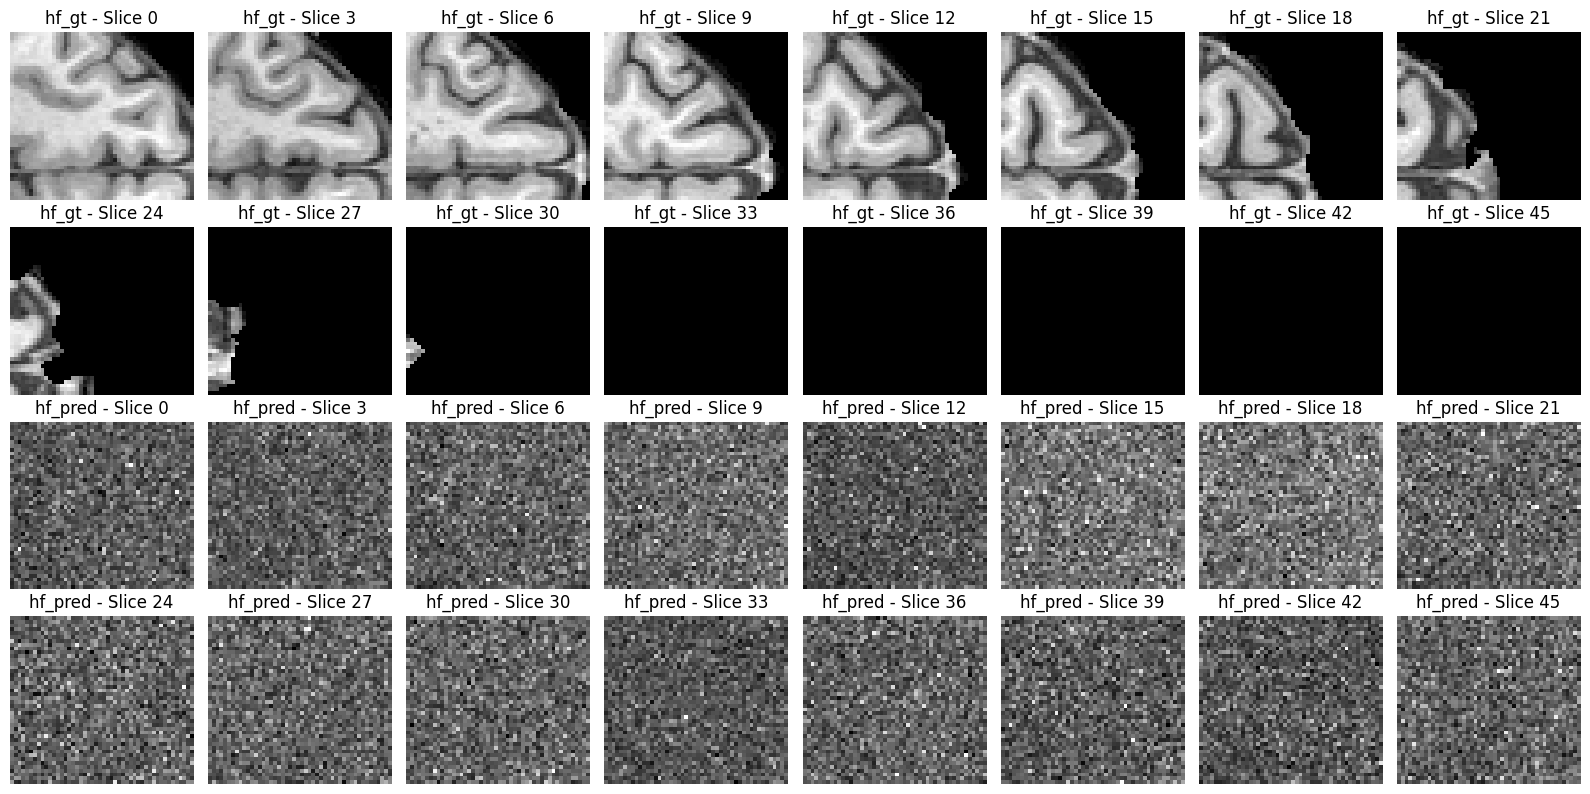

40it [00:07,  5.37it/s]
40it [00:07,  5.38it/s]
40it [00:07,  5.38it/s]
40it [00:07,  5.34it/s]
40it [00:07,  5.28it/s]
40it [00:07,  5.39it/s]
40it [00:07,  5.42it/s]
40it [00:07,  5.35it/s]
40it [00:07,  5.35it/s]
40it [00:07,  5.38it/s]
40it [00:07,  5.26it/s]
40it [00:07,  5.19it/s]
40it [00:07,  5.19it/s]
40it [00:08,  4.98it/s]
40it [00:08,  4.97it/s]
40it [00:07,  5.23it/s]
40it [00:07,  5.21it/s]
40it [00:07,  5.23it/s]
40it [00:07,  5.17it/s]
40it [00:07,  5.11it/s]
40it [00:07,  5.19it/s]
40it [00:07,  5.22it/s]
40it [00:07,  5.48it/s]
40it [00:07,  5.37it/s]
40it [00:07,  5.39it/s]
40it [00:07,  5.36it/s]
40it [00:07,  5.28it/s]
40it [00:07,  5.31it/s]
40it [00:07,  5.45it/s]
40it [00:07,  5.52it/s]
40it [00:07,  5.29it/s]
40it [00:07,  5.34it/s]
40it [00:07,  5.40it/s]
40it [00:07,  5.28it/s]
40it [00:07,  5.44it/s]
40it [00:07,  5.53it/s]
40it [00:07,  5.52it/s]
40it [00:07,  5.18it/s]
40it [00:07,  5.30it/s]
40it [00:07,  5.06it/s]
40it [00:08,  4.78it/s]
40it [00:07,  5.

Epoch 150/500  loss: 0.051871


40it [00:07,  5.30it/s]
40it [00:07,  5.50it/s]
40it [00:07,  5.45it/s]
40it [00:07,  5.33it/s]
40it [00:07,  5.37it/s]
40it [00:07,  5.17it/s]
34it [00:07,  4.73it/s]


KeyboardInterrupt: 

In [8]:
chunk_size = patch_size
for epoch in range(epochs):
    running_loss = 0.0
    n_batches = 0
    for idx, batch in tqdm(enumerate(loader)):
        # batch is a dict; images accessible as batch['low'][tio.DATA] and batch['high'][tio.DATA]

        # low_patches = batch['low'][tio.DATA].to(device)   # (B,1,pw,ph,pd)
        high_patches = batch["hf_gt_scalar"][tio.DATA].to(device) # (B,1,pw,ph,pd)

        # B = low_patches.shape[0]
        hf_target = high_patches.view(B, 1, -1).permute(0,2,1)  # (B,*N,1)

        # Make coords batch: (B,N,3)
        coords_batched = coords_patch.unsqueeze(0).expand(B, -1, -1)  # (B,*N,3)

        optimizer.zero_grad()
        # preds = model(coords_batched)  # (B,N,1)
        model_output_seg_pre, model_output_seg, model_output_img_pre , model_output_img, coords = model(coords_batched)
                
        model_output_img_dice = torch.stack((model_output_img[:,:,3].reshape(chunk_size), model_output_img[:,:,0].reshape(chunk_size), model_output_img[:,:,1].reshape(chunk_size), model_output_img[:,:,2].reshape(chunk_size)), dim=0).unsqueeze(0)
        hf_pred = model_output_img_dice[0,0] + model_output_img_dice[0,1] + model_output_img_dice[0,2] #+ model_output_img_dice[0,3]
        
        loss = loss_fn(hf_pred.flatten(), hf_target.flatten())
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        n_batches += 1
    if(epoch%100 == 0):
        clear_output(True)
        fig = visualize_volume_slices(hf_target.flatten().view(patch_size).permute(2,0,1).detach().cpu(), hf_pred.flatten().view(patch_size).permute(2,0,1).detach().cpu(), axis=0, num_slices=16, title1='hf_gt', title2='hf_pred')
        plt.show()

    epoch_loss = running_loss / max(1, n_batches)
    if (epoch+1) % max(1, epochs//10) == 0 or epoch==0:
        print(f"Epoch {epoch+1}/{epochs}  loss: {epoch_loss:.6f}")

In [109]:
hf_pred.flatten().view(patch_size).permute(2,0,1).shape

torch.Size([48, 44, 48])

In [23]:
icbm = tio.datasets.ICBM2009CNonlinearSymmetric('t1')
img = icbm.t1[0] # scalar image
img = img.resample((128,128,128)) 

AttributeError: 'ScalarImage' object has no attribute 'resample'

In [18]:
icbm.t1[0]

ScalarImage(shape: (1, 1, 229, 193); spacing: (1.00, 1.00, 1.00); orientation: RAS+; dtype: torch.FloatTensor; memory: 172.6 KiB)

In [29]:
import torch, torch.nn as nn, torch.nn.functional as F
import torchio as tio
import math
from torch.utils.data import DataLoader

from Models.models import Siren, Finer
from Utils.utils import get_full_img, norm, get_device, dice_stack_helper, get_model, ClearCache
from Data.load_data_3d import load_data, get_gt_seg
from Utils.defaults import default_config
from Utils.plotting_utils2 import plot_seg_results_paper, plot_final_results_paper, plot_hf_results_paper
from Utils.plotting_utils import loss_plot, plot_image_metrics, plot_4_images
from LFSynth.ContrastModulation import ContrastModulation
from test3D import visualize_volume_slices

# --- SIREN INR Setup ---
class SineLayer(nn.Module):
    def __init__(self, in_features, out_features, is_first=False, omega_0=30):
        super().__init__()
        self.is_first, self.omega_0 = is_first, omega_0
        self.lin = nn.Linear(in_features, out_features)
        self.init_weights()

    def init_weights(self):
        with torch.no_grad():
            if self.is_first:
                self.lin.weight.uniform_(-1/self.lin.in_features, 1/self.lin.in_features)
            else:
                bound = math.sqrt(6/self.lin.in_features)/self.omega_0
                self.lin.weight.uniform_(-bound, bound)

    def forward(self, x):
        return torch.sin(self.omega_0 * self.lin(x))

class SIREN(nn.Module):
    def __init__(self, in_f=3, hidden=128, hidden_layers=2, out_f=1, omega_0=30):
        super().__init__()
        layers = [SineLayer(in_f, hidden, is_first=True, omega_0=omega_0)]
        for _ in range(hidden_layers):
            layers.append(SineLayer(hidden, hidden, omega_0=omega_0))
        layers.append(nn.Linear(hidden, out_f))
        self.net = nn.Sequential(*layers)

    def forward(self, coords):
        return self.net(coords)

# Generate normalized coords
def make_coords(shape, device):
    z, y, x = [torch.linspace(0,s-1,s,device=device) for s in shape]
    zz, yy, xx = torch.meshgrid(z, y, x, indexing='ij')
    coords = torch.stack([zz, yy, xx], dim=-1)
    for i in range(3):
        coords[...,i] = 2*(coords[...,i]/(shape[i]-1)) - 1
    return coords.view(-1,3)

# --- TorchIO Dataset ---
class PatchINRDataset(torch.utils.data.Dataset):
    def __init__(self, image, patch_size=(32,32,32), num_patches=20):
        self.img = image
        self.queue = tio.Queue(
            subjects_dataset=[tio.Subject(img=self.img)],
            max_length=num_patches,
            samples_per_volume=num_patches,
            sampler=tio.data.UniformSampler(patch_size),
            num_workers=1
        )
        self.patch_size = patch_size

    def __len__(self):
        return len(self.queue)

    def __getitem__(self, idx):
        patch = self.queue[idx]
        # vol = patch['img'][tio.DATA][0]   # (D,H,W)
        vol = image
        coords = make_coords(vol.shape, vol.device)  # local normalized
        target = vol.view(-1,1)
        return coords, target

# --- Training and Inference ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load a single real 3D brain MRI
config = copy.deepcopy(default_config)
config["in_features"] = 3
hf_ground_truth, lf_gt, prior_seg_dice, lf_gt_seg_dice, M = load_data(1, config) #uncomment



In [31]:
# Create Dataset with patches
ds = PatchINRDataset(tio.ScalarImage(tensor=torch.tensor(torch.from_numpy(norm(hf_ground_truth)).unsqueeze(0), dtype=torch.float32)), patch_size=(44,48,48), num_patches=50)
loader = DataLoader([ds], batch_size=1, shuffle=True)

In [33]:
next(iter(loader))

TypeError: default_collate: batch must contain tensors, numpy arrays, numbers, dicts or lists; found <class '__main__.PatchINRDataset'>

In [32]:
model = SIREN().to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-4)
loss_fn = nn.MSELoss()

# Training
print("Training on real MRI template...")
for epoch in range(2):
    total = 0.0
    for coords, target in loader:
        coords, target = coords.to(device), target.to(device)
        pred = model(coords)
        loss = loss_fn(pred, target)
        opt.zero_grad(); loss.backward(); opt.step()
        total += loss.item()
    if (epoch+1)%50 == 0:
        print(f"Epoch {epoch+1}, Loss: {total/len(loader):.6f}")


Training on real MRI template...


TypeError: default_collate: batch must contain tensors, numpy arrays, numbers, dicts or lists; found <class '__main__.PatchINRDataset'>